In [60]:
#import necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
#Creating user defined function to calculate b0 and b1. b0 is constant, b1 is slope.

def estimate_coefficients(x,y):
  n = np.size(x)
  mean_x = np.mean(x)
  mean_y = np.mean(y)
  SS_xy = np.sum((y*x)-n*mean_x*mean_y)
  SS_xx = np.sum((x*x)-n*mean_x*mean_x)
  b1 = SS_xy/SS_xx
  b0 = mean_y - b1*mean_x
  return (b0,b1)

In [62]:
x = np.array([1,2,3,4,5])
y = np.array([4,3,4,2,5])

b = estimate_coefficients(x,y)
print("b0 = ", b[0])
print("b1 = ", b[1])

b0 =  -0.19411764705882328
b1 =  1.2647058823529411


In [63]:
y_pred = b[0] + b[1]*x
y_pred

array([1.07058824, 2.33529412, 3.6       , 4.86470588, 6.12941176])

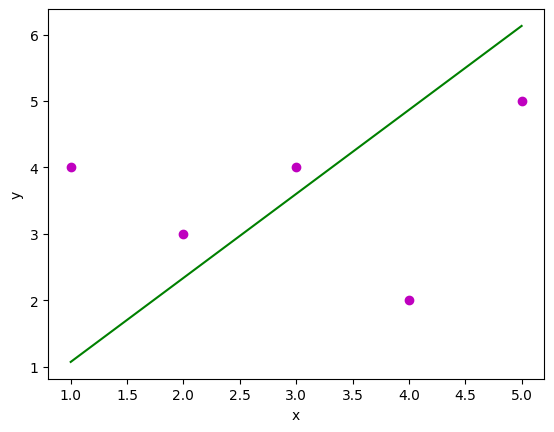

In [64]:
#plot the regression lines or equation
plt.scatter(x,y,color ='m',marker ='o')
plt.plot(x,y_pred, color='g')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [65]:
# load the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal-length','sepal-width','petal-length','petal-width','class']
df = pd.read_csv(url, names=names)
df.head()

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [67]:
df.describe(include='all')

,sepal-length,sepal-width,petal-length,petal-width,class
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [68]:
# OLS method - Ordinary Least square method
#Find the linear regression equation (simple or multiple)
#Y = b0 + b1X1 +b2X2 +...+bnXn
#ols(Dep ~ list of independent variable list)

In [69]:
import statsmodels.api as sm
df = pd.read_csv('/content/Boston1.csv')
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [70]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [71]:
df.isna().sum() # will give number of missing values in each variable.

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [72]:
#checking for duplicates
df.duplicated().sum() # to check for redundancy in the data also to avoid over trainging of models.
#There is 0 duplicate rows

np.int64(0)

In [73]:
#Visualization - Univariate
#We will consider only three independent variables and one dependent variable. [only for learning purpose.
#Independent variables(X)-> rm, ptratio, lstat
#dependent variable (Y) -> medv
#describe() -> basic statistics

In [74]:
#boxplot -> normality and outliers
#boxplot for all the variables -> distribution and presence of outliers
df[['rm','ptratio','lstat','medv']].describe(include='all')

,rm,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000
mean,6.284634,18.455534,12.653063,22.532806
std,0.702617,2.164946,7.141062,9.197104
min,3.561000,12.600000,1.730000,5.000000
25%,5.885500,17.400000,6.950000,17.025000
50%,6.208500,19.050000,11.360000,21.200000
75%,6.623500,20.200000,16.955000,25.000000
max,8.780000,22.000000,37.970000,50.000000


<Axes: >

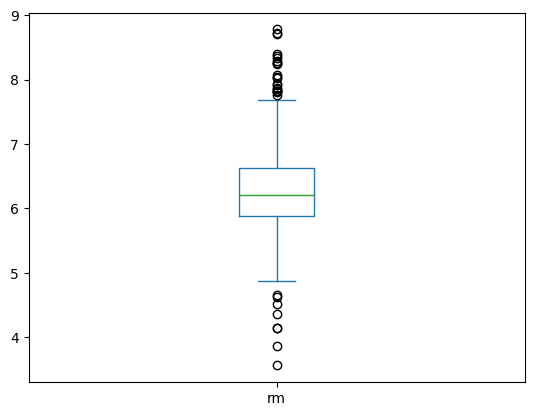

In [75]:
df['rm'].plot(kind='box')

<Axes: >

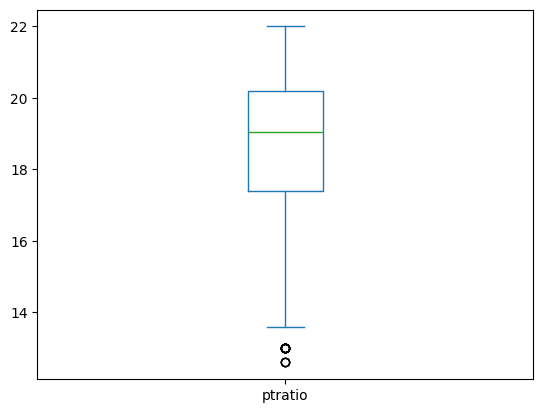

In [76]:
df['ptratio'].plot(kind='box')

<Axes: >

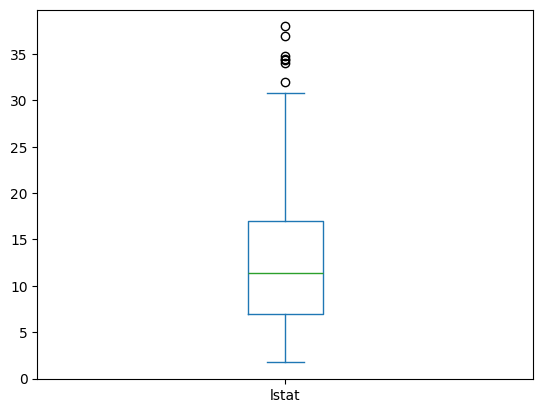

In [77]:
df['lstat'].plot(kind='box')

<Axes: >

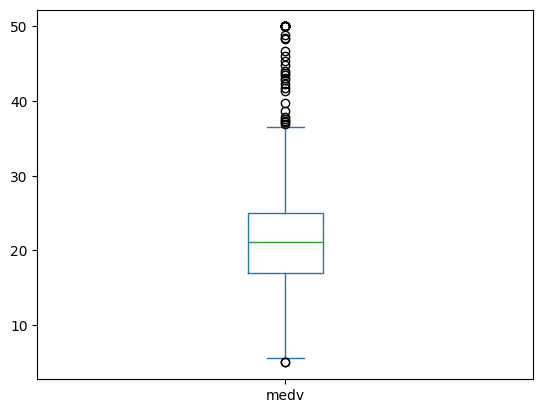

In [78]:
df['medv'].plot(kind='box')

In [79]:
#Bivariant analysis to check relationship between the indep var and target var. also between indep. var -> multi collinearity -> if multi- collinearity is present, the model may not be a good for prediction
#visually -> scatter plot or pairplot
#statistically -> correlation and heatmap

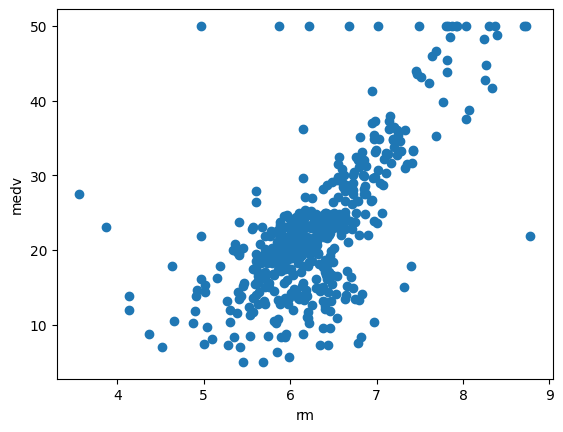

In [80]:
#scatterplot between rm and medv
# scatterplot between rm and medv
plt.scatter(df['rm'],df['medv'])
plt.xlabel('rm')
plt.ylabel('medv')
plt.show()
#positive relationship

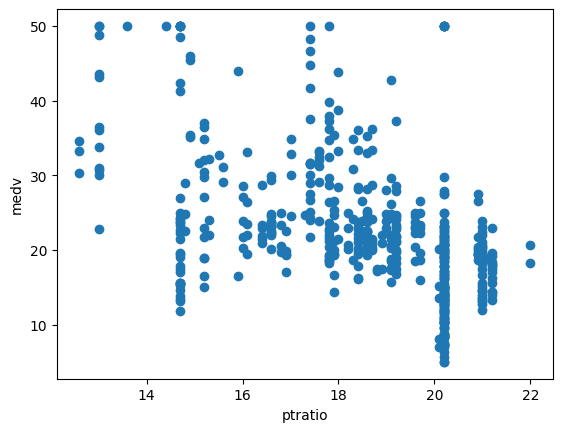

In [81]:
# scatterplot between rm and medv
plt.scatter(df['ptratio'],df['medv'])
plt.xlabel('ptratio')
plt.ylabel('medv')
plt.show()

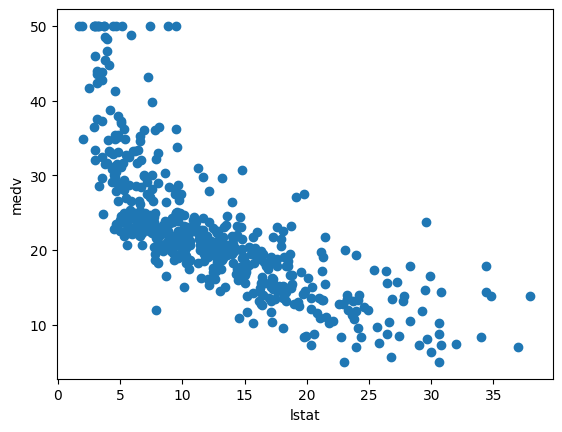

In [82]:
# scatterplot between rm and medv
plt.scatter(df['lstat'],df['medv'])
plt.xlabel('lstat')
plt.ylabel('medv')
plt.show()

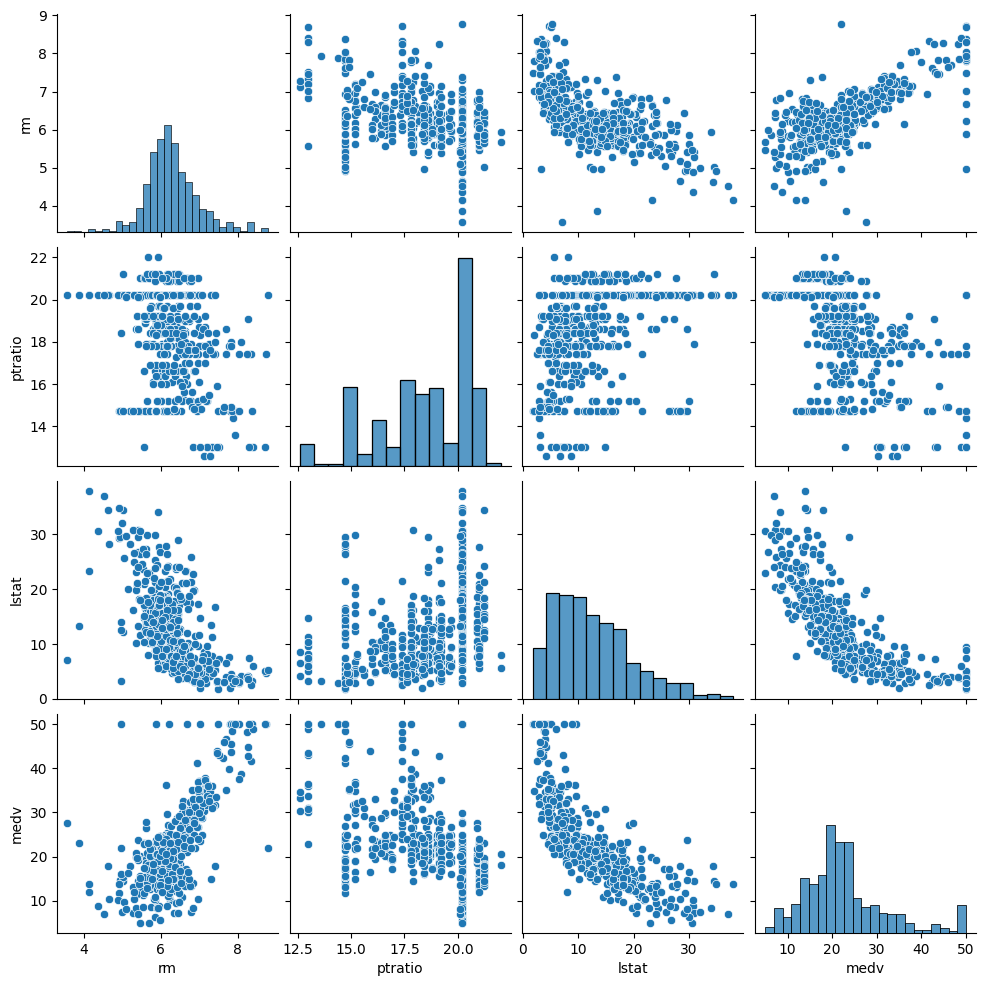

In [83]:
#pairplot
sns.pairplot(df[['rm','ptratio','lstat','medv']])

In [84]:
#correlation and heatmap
df[['rm','ptratio','lstat','medv']].corr()

,rm,ptratio,lstat,medv
rm,1.000000,-0.355501,-0.613808,0.695360
ptratio,-0.355501,1.000000,0.374044,-0.507787
lstat,-0.613808,0.374044,1.000000,-0.737663
medv,0.695360,-0.507787,-0.737663,1.000000


<Axes: >

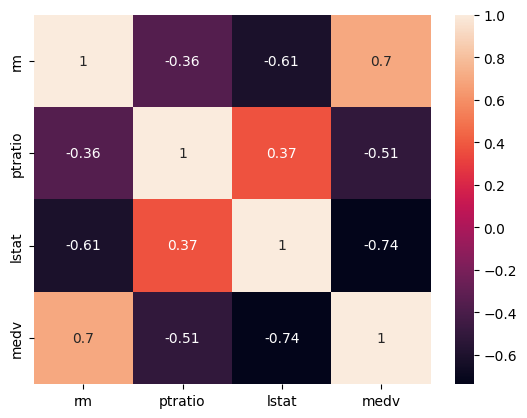

In [85]:
sns.heatmap(df[['rm','ptratio','lstat','medv']].corr(),annot=True)

In [86]:
Y =df['medv']
X = df[['rm','ptratio','lstat']]
X = sm.add_constant(X)
X

,const,rm,ptratio,lstat
0,1.0,6.575,15.3,4.98
1,1.0,6.421,17.8,9.14
2,1.0,7.185,17.8,4.03
3,1.0,6.998,18.7,2.94
4,1.0,7.147,18.7,5.33
...,...,...,...,...
501,1.0,6.593,21.0,9.67
502,1.0,6.120,21.0,9.08
503,1.0,6.976,21.0,5.64
504,1.0,6.794,21.0,6.48


In [87]:
#fit the regression line using OLS method in statsmodel
#medv = b0 +b1(rm)+b2(lstat)+b3(ptratio)
#to get the constant value in the stasmodel, we have to add a constant variable to the data.

Y =df['medv']
X = df[['rm','ptratio','lstat']]
X = sm.add_constant(X)

model = sm.OLS(Y,X)
result =model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     353.3
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          2.69e-123
Time:                        03:00:35   Log-Likelihood:                -1553.0
No. Observations:                 506   AIC:                             3114.
Df Residuals:                     502   BIC:                             3131.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.5671      3.913      4.745      0.0

In [88]:
# import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # fit and predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [89]:
#select the data for modeling
df_selected = df[['rm','ptratio','lstat','medv']]
df_selected.head(2)

,rm,ptratio,lstat,medv
0,6.575,15.3,4.98,24.0
1,6.421,17.8,9.14,21.6


In [90]:
#EDA = refer to statsmodel seciton

In [91]:
#split the data into X and Y
X = df_selected[['rm','ptratio','lstat']]
Y = df_selected[['medv']]
print(X.shape)
print(Y.shape)

(506, 3)
(506, 1)


In [92]:
X.head()

,rm,ptratio,lstat
0,6.575,15.3,4.98
1,6.421,17.8,9.14
2,7.185,17.8,4.03
3,6.998,18.7,2.94
4,7.147,18.7,5.33


In [93]:
Y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [94]:
#split the data into train and test data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

#split the data randomly with 70% for train data and 30% for test data. as we need to large data for training(80:20,70:30,75:25). thats when model can see all possible patterns in the data and learn. Learing the means, getting the optimal value for parameters (b0,b1,b2...)
#random_state = when we split the data into train and test, the data from the X and Y will be chosen at random.
#Means -> it will take 70% of the data randomly and assign to the X_train and Y_train (pairs) and 30% to the tests. since the selection happens at random, everytime when we run this line of code, the random data selected will change.

In [95]:
#Configure the model
model = LinearRegression()
model

LinearRegression()

In [96]:
#fit the model
lm = model.fit(X_train, Y_train)

In [97]:
#Get the model parameters
lm.coef_ #b0,b1,b2

array([[ 4.46162598, -0.86290452, -0.60815   ]])

In [98]:
lm.intercept_ #constant value

array([18.11908505])

In [99]:
#predict the train data
Y_train_predict = lm.predict(X_train)
Y_train_predict[:10]

array([[27.50256404],
       [22.9922606 ],
       [21.81484141],
       [22.47621327],
       [16.10224974],
       [24.49640822],
       [31.4172681 ],
       [12.06854712],
       [22.2145967 ],
       [18.7368882 ]])

In [100]:
#predict the test data
y_test_predict = lm.predict(X_test)
y_test_predict[:10]

array([[26.92298627],
       [30.93686434],
       [16.47934188],
       [25.25409179],
       [18.28052198],
       [22.71776451],
       [17.48030837],
       [12.67868396],
       [20.65299142],
       [19.72674849]])

In [101]:
#Evaluating the model --> R square, MSE (mean square error)
rsq = r2_score(Y_train, Y_train_predict)
print("R squared value for train data: ",rsq)
mse = mean_squared_error(Y_train,Y_train_predict)
print("Mean squared error for train data: ",mse)
rmse = np.sqrt(mse)
print("Root Mean squared error for train data:", rmse)

R squared value for train data:  0.6850018441906278
Mean squared error for train data:  27.687244667341563
Root Mean squared error for train data: 5.261867032464956


In [102]:
#metrics for test data
rsq = r2_score(Y_test, y_test_predict)
print("R squared value for test data: ",rsq)
mse = mean_squared_error(Y_test,y_test_predict)
print("Mean squared error for test data: ",mse)
rmse = np.sqrt(mse)
print("Root Mean squared error for test data:", rmse)

R squared value for test data:  0.650904156861472
Mean squared error for test data:  26.01221192212625
Root Mean squared error for test data: 5.100216850500207


In [103]:
X_train.head(1)

,rm,ptratio,lstat
5,6.43,18.7,5.21


In [104]:
#how to predict for new data
x_new = [7.5,19,7]
y_new_predict = lm.predict([x_new])
y_new_predict

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[30.92904398]])

In [105]:
#how to fine tune the model.

#1. feature engineering -> adding or removing the independent variables. or deriving new variable from the existing variables and add that to the model - This is case by case decision
#2. hyper-parameter tunning -> changing the hyper parameters. but for linear regression there are no hyperparamenters.

In [106]:
#Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df1 = pd.read_csv('/content/heart1.csv')
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,1


In [107]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  target    303 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 30.9 KB


In [108]:
#split X and Y
X=df1.drop('target', axis=1)
Y=df1['target']

In [109]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca
0,63,1,3,145,233,1,0,150,0,2.3,0,0
1,37,1,2,130,250,0,1,187,0,3.5,0,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0


In [110]:
Y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [113]:
#split train and test
X_train , X_test,Y_test,Y_train=train_test_split(X,Y,test_size=0.3,random_state=1)
print(X_train.shape)


(212, 12)
